In [1]:
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(
    model="gpt-4o",
    base_url= os.getenv("AICREDITS_BASE_URL"),
    api_key = os.getenv("AICREDITS_API_KEY")
)

## Mock ReACT application

In [2]:
##A mocked Search and calculator tool
import math

def mocked_google_search(query: str) -> str:
    print(f"CALLED GOOGLE SEARCH with query={query}")
    return "Donald Trump is the president of USA and he's 80 years old"

def mocked_calculator(expression: str) -> float:
    print(f"CALLED CALCULATOR with expression={expression}")
    if "sqrt" in expression:
        return math.sqrt(78*132)
    return 78*132
    

### Defining a schema for our tools

In [3]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

calculator_tool = {
    "title": "calculator",
    "description": "Computes mathematical expression",
    "type": "object",
    "properties":{
        "expression":{
            "description": "A mathematical expression to be evaluated by a calculator",
            "title": "expression",
            "type": "string"},
    },
    "required": ["expression"]
}

search_tool = {
    "title": "google_search",
    "description": "Returns about fresh events and news from Google search engine based on a query",
    "type": "object",
    "properties": {
        "query":{
            "description": "Search query to be sent to the search engine",
            "title": "search_query",
            "type": "string"},
    },
    "required":["query"]
}

prompt = ChatPromptTemplate([
    ("system", """Always use a calculator for mathematical computations, and 
    google search for information about fresh events abnd news."""), 
    MessagesPlaceholder(variable_name= "messages"),
])

In [4]:
llm_with_tools = prompt | llm.bind_tools([search_tool, calculator_tool])

### Defining the LangGraph workflow

In [5]:
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from typing import TypedDict

def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def call_tools(state: MessagesState):
    last_message = state["messages"][-1]
    tool_calls = last_message.tool_calls

    new_message = []

    for tool_call in tool_calls:
        if tool_call["name"] == "google_search":
            tool_result = mocked_google_search(**tool_call["args"])
            new_message.append(ToolMessage(content=tool_result, tool_call_id= tool_call["id"]))
        elif tool_call["name"] == "calculator":
            tool_result = mocked_calculator(**tool_call["args"])
            new_message.append(ToolMessage(content=tool_result, tool_call_id= tool_call["id"]))
        else:
            #raise ValueError(f"""Tool {tool_call["name"]} is not defined!""")
            raise ValueError(f"Tool {tool_call['name']} is not defined!")
    return {"messages": new_message}

def should_run_tools(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "call_tools"
    return END


### putting it all together

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("call_tools", call_tools)

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", should_run_tools)
builder.add_edge("call_tools", "invoke_llm")
graph = builder.compile()

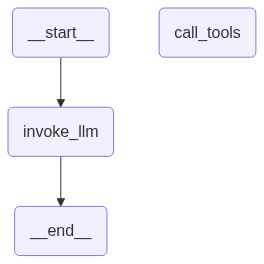

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
question = "what is the square root of the current US president's age multiplied by 132?"

In [9]:
result = graph.invoke({"messages": [HumanMessage(content=question)]})

CALLED GOOGLE SEARCH with query=current US president age
CALLED CALCULATOR with expression=sqrt(80) * 132


In [10]:
print(result["messages"][-1].content)

The square root of the current U.S. president's (Joe Biden's) age (which is 80) multiplied by 132 is approximately 101.47.


### implementing the above with pre-built agent from LangGraph

In [17]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool


@tool("google_search")
def mocked_google_search_tool(query: str) -> str:
    """Returns about common facts, fresh events and news from Google Search engine based on a query."""
    return mocked_google_search(query)


@tool("calculator")
def mocked_calculator_tool(expression: str) -> str:
    """Computes mathematical expressions"""
    return str(mocked_calculator(expression))

system_prompt = (
    "Always use a calculator for mathematical computations, and use Google Search "
    "for information about common facts, fresh events and news. Do not assume anything, keep in "
    "mind that things are changing and always "
    "check yourself with external sources if possible."
)

agent = create_react_agent(
    model=llm,
    tools=[mocked_google_search_tool, mocked_calculator_tool],
    prompt=system_prompt,
)

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_4356\2597617326.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [18]:
agent_result = agent.invoke({"messages": [HumanMessage(content=question)]})
print(agent_result["messages"][-1].content)

CALLED GOOGLE SEARCH with query=current US president age 2023
CALLED CALCULATOR with expression=sqrt(80 * 132)
The square root of the current US president's age (80 years old) multiplied by 132 is approximately 101.47.
